<a href="https://colab.research.google.com/github/mohamadfaisalbashir/Practical-Linear-Algebra/blob/main/Chapter_13_Eigendecomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Eigendecomposition**

This notebook covers Eigendecomposition:
1. Eigenvalues and Eigenvectors
2. Computing Eigendecomposition
3. Properties of Symmetric Matrices
4. Applications
5. Polynomial Regression
5. Quadratic Forms and Definiteness
6. Summary


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 8)

## **1. Eigenvalues and Eigenvectors**

For a square matrix A, an eigenvector v is a non-zero vector such that multiplying A by v produces a scalar multiple of v:

A v = λ v

where λ is called the eigenvalue corresponding to eigenvector v.

This equation can be rewritten as:
(A - λI) v = 0

For this homogeneous system to have a non-trivial solution (v ≠ 0), the matrix (A - λI) must be singular, which means:
det(A - λI) = 0

This determinant is the **characteristic polynomial** of A. Its roots are the eigenvalues.

### **Geometric Interpretation**

Geometrically, an eigenvector is a direction that is not rotated by the matrix transformation. When A is applied to an eigenvector, the result is simply a scaled version of that vector—the scaling factor is the eigenvalue.

In [2]:
# Example: 2x2 symmetric matrix
A = np.array([[3, 1],
              [1, 3]], dtype=float)

print('EIGENVALUES AND EIGENVECTORS')
print('=' * 70)
print(f'Matrix A:')
print(A)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print(f'\nEigenvalues: {eigenvalues}')
print(f'\nEigenvectors (as columns):')
print(eigenvectors)

# Verify: A @ v = λ @ v
print(f'\nVerification: A @ v = λ v')
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lambda_i = eigenvalues[i]

    Av = A @ v
    lambda_v = lambda_i * v

    print(f'\nEigenvector {i}: {v}')
    print(f'A @ v = {Av}')
    print(f'λ * v = {lambda_v}')
    print(f'Match: {np.allclose(Av, lambda_v)}')

EIGENVALUES AND EIGENVECTORS
Matrix A:
[[3. 1.]
 [1. 3.]]

Eigenvalues: [4. 2.]

Eigenvectors (as columns):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Verification: A @ v = λ v

Eigenvector 0: [0.70710678 0.70710678]
A @ v = [2.82842712 2.82842712]
λ * v = [2.82842712 2.82842712]
Match: True

Eigenvector 1: [-0.70710678  0.70710678]
A @ v = [-1.41421356  1.41421356]
λ * v = [-1.41421356  1.41421356]
Match: True


## **2. Computing Eigendecomposition**

### **The Eigendecomposition Formula**

If a matrix A is diagonalizable, it can be decomposed as:

A = Q Λ Q^(-1)

where:
- Q is the matrix of eigenvectors (one eigenvector per column)
- Λ is the diagonal matrix of eigenvalues
- Q^(-1) is the inverse of Q

This decomposition allows us to understand the action of matrix A as:
1. Transform to the eigenvector basis (Q^(-1))
2. Scale by eigenvalues (Λ)
3. Transform back to original basis (Q)

### **Powers of Matrices**

The eigendecomposition enables efficient computation of matrix powers:

A^n = Q Λ^n Q^(-1)

Since Λ is diagonal, Λ^n is simply the diagonal matrix with each eigenvalue raised to the nth power.

In [3]:
print('EIGENDECOMPOSITION: A = Q Λ Q^(-1)')
print('=' * 70)

# Compute eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(A)

Q = eigenvectors
Lambda = np.diag(eigenvalues)
Q_inv = np.linalg.inv(Q)

print(f'\nQ (eigenvector matrix):')
print(Q)
print(f'\nΛ (eigenvalue diagonal matrix):')
print(Lambda)
print(f'\nQ^(-1):')
print(Q_inv)

# Verify: A = Q Λ Q^(-1)
A_reconstructed = Q @ Lambda @ Q_inv
print(f'\nReconstructed A = Q Λ Q^(-1):')
print(A_reconstructed)
print(f'\nMatches original A: {np.allclose(A_reconstructed, A)}')

# Computing matrix powers using eigendecomposition
print(f'\n\nMATRIX POWERS using eigendecomposition:')
print('='*70)

n = 3
# Using eigendecomposition
Lambda_n = np.diag(eigenvalues ** n)
A_power_eigen = Q @ Lambda_n @ Q_inv

# Direct computation
A_power_direct = np.linalg.matrix_power(A, n)

print(f'\nA^{n} using eigendecomposition:')
print(A_power_eigen)
print(f'\nA^{n} using direct computation:')
print(A_power_direct)
print(f'\nMethods match: {np.allclose(A_power_eigen, A_power_direct)}')

EIGENDECOMPOSITION: A = Q Λ Q^(-1)

Q (eigenvector matrix):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Λ (eigenvalue diagonal matrix):
[[4. 0.]
 [0. 2.]]

Q^(-1):
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

Reconstructed A = Q Λ Q^(-1):
[[3. 1.]
 [1. 3.]]

Matches original A: True


MATRIX POWERS using eigendecomposition:

A^3 using eigendecomposition:
[[36. 28.]
 [28. 36.]]

A^3 using direct computation:
[[36. 28.]
 [28. 36.]]

Methods match: True


## **3. Properties of Symmetric Matrices**

### **Special Properties**

Symmetric matrices (A = A^T) have special properties that make them particularly nice to work with:

1. **All eigenvalues are real**: No complex eigenvalues
2. **Eigenvectors are orthogonal**: Eigenvectors corresponding to different eigenvalues are orthogonal
3. **Orthogonal diagonalization**: Q is orthogonal, so Q^(-1) = Q^T

These properties mean that for symmetric A:
A = Q Λ Q^T

where Q is an orthogonal matrix (Q^T Q = I).

### **The Spectral Theorem**

The **Spectral Theorem** states that any symmetric matrix can be expressed as:
A = ∑ᵢ λᵢ vᵢ vᵢ^T

where λᵢ are eigenvalues and vᵢ are corresponding orthonormal eigenvectors. This expresses the matrix as a sum of rank-1 matrices, each weighted by an eigenvalue.

In [4]:
print('PROPERTIES OF SYMMETRIC MATRICES')
print('=' * 70)

# Verify matrix is symmetric
print(f'A = A^T (symmetric): {np.allclose(A, A.T)}')

# Check that eigenvalues are real
eigenvalues_sym, eigenvectors_sym = np.linalg.eig(A)
print(f'\nEigenvalues: {eigenvalues_sym}')
print(f'All real: {np.all(np.isreal(eigenvalues_sym))}')

# Check orthogonality of eigenvectors
print(f'\nOrthogonality of eigenvectors:')
Q_sym = eigenvectors_sym
for i in range(Q_sym.shape[1]):
    for j in range(i+1, Q_sym.shape[1]):
        dot_product = np.dot(Q_sym[:, i], Q_sym[:, j])
        print(f'v_{i} · v_{j} = {dot_product:.10f}')

# Verify orthogonal diagonalization
print(f'\nOrthogonal diagonalization: A = Q Λ Q^T')
Q_T = Q_sym.T
Lambda_sym = np.diag(eigenvalues_sym)
A_reconstructed_sym = Q_sym @ Lambda_sym @ Q_T
print(f'Reconstructed A matches: {np.allclose(A_reconstructed_sym, A)}')

# Verify Q is orthogonal
print(f'\nQ is orthogonal (Q^T Q = I):')
print(Q_sym.T @ Q_sym)
print(f'Is identity: {np.allclose(Q_sym.T @ Q_sym, np.eye(A.shape[0]))}')

# Spectral decomposition
print(f'\nSpectral Decomposition: A = Σ λᵢ vᵢ vᵢ^T')
A_spectral = np.zeros_like(A)
for i in range(len(eigenvalues_sym)):
    lambda_i = eigenvalues_sym[i]
    v_i = Q_sym[:, i:i+1]  # As column vector
    A_spectral += lambda_i * (v_i @ v_i.T)

print(f'\nReconstructed A from spectral decomposition:')
print(A_spectral)
print(f'\nMatches original A: {np.allclose(A_spectral, A)}')

PROPERTIES OF SYMMETRIC MATRICES
A = A^T (symmetric): True

Eigenvalues: [4. 2.]
All real: True

Orthogonality of eigenvectors:
v_0 · v_1 = 0.0000000000

Orthogonal diagonalization: A = Q Λ Q^T
Reconstructed A matches: True

Q is orthogonal (Q^T Q = I):
[[1. 0.]
 [0. 1.]]
Is identity: True

Spectral Decomposition: A = Σ λᵢ vᵢ vᵢ^T

Reconstructed A from spectral decomposition:
[[3. 1.]
 [1. 3.]]

Matches original A: True


## **4. Applications: Principal Component Analysis (PCA)**

### **What is PCA?**

Principal Component Analysis is a dimensionality reduction technique that uses eigendecomposition of the covariance matrix to identify the directions of maximum variance in data. The eigenvectors of the covariance matrix are called **principal components**, and the corresponding eigenvalues indicate the amount of variance along each principal component.

### **Steps of PCA**

1. **Standardize data**: Center and scale variables to unit variance
2. **Compute covariance matrix**: Cov = (1/(n-1)) X^T X (for centered X)
3. **Eigendecomposition**: Find eigenvalues/eigenvectors of covariance matrix
4. **Select components**: Choose first k principal components based on explained variance
5. **Transform data**: Project data onto principal components

### **Benefits**

- **Dimensionality reduction**: Reduce number of features while preserving most variance
- **Visualization**: Project high-dimensional data to 2D/3D for visualization
- **Noise reduction**: Removing low-variance components removes noise
- **Feature extraction**: Principal components can be used as new features

PRINCIPAL COMPONENT ANALYSIS (PCA)
Data shape: (200, 4)

Eigenvalues (variance explained): [1.92470013 0.97130414 0.689161   0.43493523]

Principal Components (eigenvectors):
[[ 0.56402909  0.25795005 -0.48768303  0.61440884]
 [ 0.58642146 -0.23687051 -0.32996943 -0.70080126]
 [ 0.39684973  0.67671127  0.59447484 -0.17655542]
 [ 0.42484273 -0.64762334  0.54761767  0.31655576]]

Explained Variance Ratio:
  PC1: 0.4788 (cumulative: 0.4788)
  PC2: 0.2416 (cumulative: 0.7204)
  PC3: 0.1714 (cumulative: 0.8918)
  PC4: 0.1082 (cumulative: 1.0000)

Projected data shape: (200, 2)
Variance retained: 0.7204


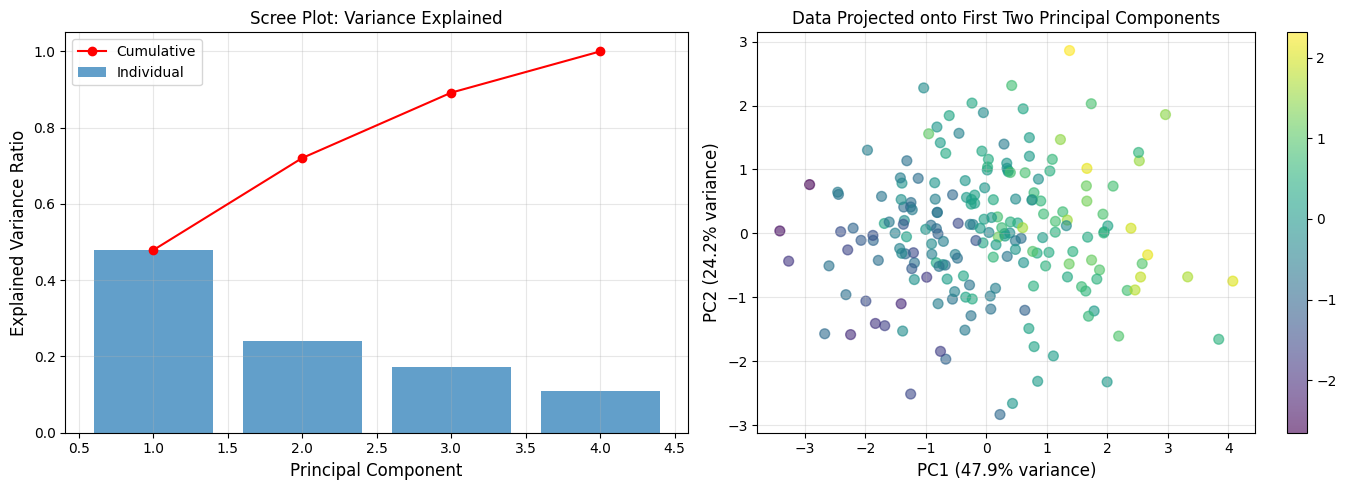

In [5]:
# Create synthetic dataset
n_samples = 200
n_features = 4

# Generate correlated features
X_original = np.random.randn(n_samples, n_features)
# Create correlations
X_original[:, 1] += 0.7 * X_original[:, 0]
X_original[:, 2] += 0.5 * X_original[:, 0]
X_original[:, 3] += 0.3 * X_original[:, 1]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_original)

print('PRINCIPAL COMPONENT ANALYSIS (PCA)')
print('=' * 70)
print(f'Data shape: {X_scaled.shape}')

# Method 1: Manual PCA using eigendecomposition
# Compute covariance matrix
Cov = (1 / (n_samples - 1)) * (X_scaled.T @ X_scaled)

# Eigendecomposition
eigenvalues_cov, eigenvectors_cov = np.linalg.eig(Cov)

# Sort by eigenvalues (descending)
idx = eigenvalues_cov.argsort()[::-1]
eigenvalues_sorted = eigenvalues_cov[idx]
eigenvectors_sorted = eigenvectors_cov[:, idx]

print(f'\nEigenvalues (variance explained): {eigenvalues_sorted}')
print(f'\nPrincipal Components (eigenvectors):')
print(eigenvectors_sorted)

# Explained variance ratio
explained_variance_ratio = eigenvalues_sorted / eigenvalues_sorted.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f'\nExplained Variance Ratio:')
for i, (ev, evr, cum) in enumerate(zip(eigenvalues_sorted, explained_variance_ratio, cumulative_variance)):
    print(f'  PC{i+1}: {evr:.4f} (cumulative: {cum:.4f})')

# Project data onto principal components
n_components = 2
W = eigenvectors_sorted[:, :n_components]
X_projected = X_scaled @ W

print(f'\nProjected data shape: {X_projected.shape}')
print(f'Variance retained: {cumulative_variance[n_components-1]:.4f}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, alpha=0.7, label='Individual')
axes[0].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'ro-', label='Cumulative')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot: Variance Explained')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Projected data
scatter = axes[1].scatter(X_projected[:, 0], X_projected[:, 1], c=X_original[:, 0], cmap='viridis', s=50, alpha=0.6)
axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)', fontsize=12)
axes[1].set_title('Data Projected onto First Two Principal Components')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1])

plt.tight_layout()
plt.show()

## **5. Quadratic Forms and Matrix Definiteness**

### **Quadratic Forms**

A **quadratic form** is a scalar-valued function of a vector:

Q(x) = x^T A x

where A is a square matrix. Quadratic forms appear throughout mathematics and applications, particularly in optimization and statistics.

### **Matrix Definiteness**

A symmetric matrix A is:
- **Positive definite**: x^T A x > 0 for all x ≠ 0 (all eigenvalues > 0)
- **Positive semi-definite**: x^T A x ≥ 0 for all x (all eigenvalues ≥ 0)
- **Negative definite**: x^T A x < 0 for all x ≠ 0 (all eigenvalues < 0)
- **Indefinite**: x^T A x can be both positive and negative (eigenvalues have mixed signs)

### **Eigenvalues Determine Definiteness**

The sign of eigenvalues completely determines matrix definiteness. This is because for symmetric A = Q Λ Q^T:

x^T A x = x^T Q Λ Q^T x = (Q^T x)^T Λ (Q^T x) = y^T Λ y = ∑ᵢ λᵢ yᵢ²

where y = Q^T x. The definiteness of the matrix depends entirely on the signs of eigenvalues λᵢ.

In [6]:
print('MATRIX DEFINITENESS AND QUADRATIC FORMS')
print('=' * 70)

# Example 1: Positive definite
A_pd = np.array([[2, 1],
                 [1, 2]], dtype=float)
evals_pd = np.linalg.eigvalsh(A_pd)

print(f'\n1. Positive Definite Matrix:')
print(f'A = \n{A_pd}')
print(f'Eigenvalues: {evals_pd}')
print(f'All positive: {np.all(evals_pd > 0)}')

# Example 2: Positive semi-definite
A_psd = np.array([[2, 1],
                  [1, 0.5]], dtype=float)
evals_psd = np.linalg.eigvalsh(A_psd)

print(f'\n2. Positive Semi-Definite Matrix:')
print(f'A = \n{A_psd}')
print(f'Eigenvalues: {evals_psd}')
print(f'All non-negative: {np.all(evals_psd >= -1e-10)}')

# Example 3: Indefinite
A_indef = np.array([[2, 1],
                    [1, -2]], dtype=float)
evals_indef = np.linalg.eigvalsh(A_indef)

print(f'\n3. Indefinite Matrix:')
print(f'A = \n{A_indef}')
print(f'Eigenvalues: {evals_indef}')
print(f'Mixed signs: {evals_indef[0] > 0 and evals_indef[1] < 0}')

# Verify with quadratic forms
print(f'\nQuadratic Forms (x^T A x):')
test_vectors = [np.array([1, 0]), np.array([0, 1]), np.array([1, 1]), np.array([1, -1])]

for A, label in [(A_pd, 'PD'), (A_psd, 'PSD'), (A_indef, 'Indef')]:
    print(f'\n{label} Matrix:')
    for v in test_vectors:
        q = v @ A @ v
        print(f'  x = {v}: x^T A x = {q:7.2f}')

MATRIX DEFINITENESS AND QUADRATIC FORMS

1. Positive Definite Matrix:
A = 
[[2. 1.]
 [1. 2.]]
Eigenvalues: [1. 3.]
All positive: True

2. Positive Semi-Definite Matrix:
A = 
[[2.  1. ]
 [1.  0.5]]
Eigenvalues: [0.  2.5]
All non-negative: True

3. Indefinite Matrix:
A = 
[[ 2.  1.]
 [ 1. -2.]]
Eigenvalues: [-2.23606798  2.23606798]
Mixed signs: False

Quadratic Forms (x^T A x):

PD Matrix:
  x = [1 0]: x^T A x =    2.00
  x = [0 1]: x^T A x =    2.00
  x = [1 1]: x^T A x =    6.00
  x = [ 1 -1]: x^T A x =    2.00

PSD Matrix:
  x = [1 0]: x^T A x =    2.00
  x = [0 1]: x^T A x =    0.50
  x = [1 1]: x^T A x =    4.50
  x = [ 1 -1]: x^T A x =    0.50

Indef Matrix:
  x = [1 0]: x^T A x =    2.00
  x = [0 1]: x^T A x =   -2.00
  x = [1 1]: x^T A x =    2.00
  x = [ 1 -1]: x^T A x =   -2.00


## **6. Summary**

Eigendecomposition is fundamental to understanding and computing with matrices:

**Eigenvalues and Eigenvectors**: The characteristic equation det(A - λI) = 0 gives eigenvalues, and the eigenvectors are computed from the null space of (A - λI). Geometrically, eigenvectors represent directions not rotated by the transformation.

**Eigendecomposition**: Any diagonalizable matrix can be written as A = Q Λ Q^(-1), expressing it as three matrices: eigenvectors (Q), eigenvalues (Λ), and the inverse of eigenvectors. This enables efficient computation of matrix powers and other operations.

**Symmetric Matrices**: These have real eigenvalues, orthogonal eigenvectors, and satisfy A = Q Λ Q^T. The Spectral Theorem expresses symmetric matrices as sums of rank-1 components weighted by eigenvalues.

**Principal Component Analysis**: PCA uses eigendecomposition of the covariance matrix to identify directions of maximum variance in data. Principal components are eigenvectors of the covariance matrix, ordered by their explained variance.

**Matrix Definiteness**: A symmetric matrix's definiteness is determined entirely by its eigenvalues—positive definite if all eigenvalues are positive, and so on. Quadratic forms x^T A x equal ∑ λᵢ yᵢ² in the eigenvector basis.

Eigendecomposition appears throughout data science in PCA, spectral clustering, network analysis, and the analysis of linear dynamical systems. Understanding eigendecomposition is essential for modern data science.